# Monte Carlo Methods on a 7×7 GridWorld

This notebook directly applies three Monte Carlo algorithms to one $7\times7$ GridWorld:

1. First-Visit Monte Carlo Prediction
2. Every-Visit Monte Carlo Prediction
3. On-Policy First-Visit Monte Carlo Control with $\epsilon$-Greedy Exploration

For each algorithm, one complete episode is worked out manually with every reward, every backward return calculation, and every value update.

## GridWorld Definition

The state is the cell coordinate

$$
s=(r,c), \qquad r,c\in\{0,\ldots,6\}.
$$

The environment uses:

$$
S_{\text{start}}=(6,0),
\qquad
S_{\text{goal}}=(0,6),
$$

$$
\gamma=0.95,
$$

$$
R_{t+1}=
\begin{cases}
20, & S_{t+1}=(0,6),\\
-1, & \text{otherwise}.
\end{cases}
$$

Actions are

$$
\mathcal A=\{U,D,L,R\}.
$$

Blocked cells are

$$
(1,3),(2,3),(3,1),(3,2),(3,3),(5,4).
$$

An action that tries to leave the grid or enter a blocked cell leaves the agent in the same state with reward $-1$.

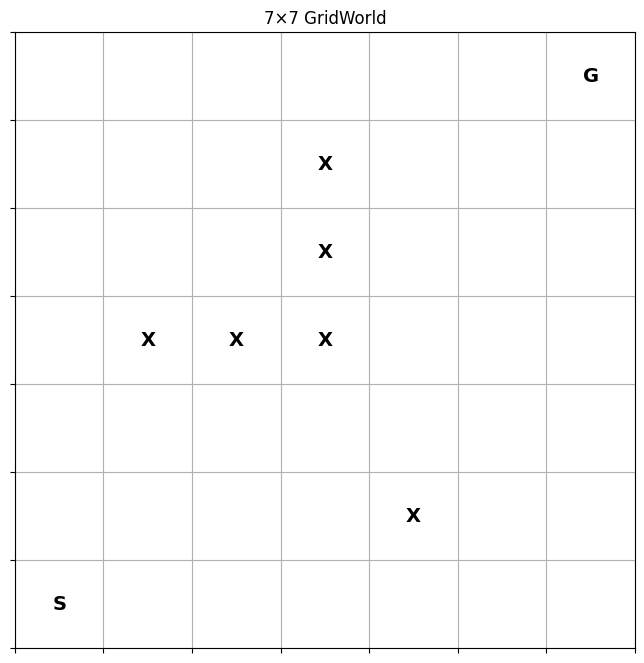

In [16]:
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROWS, COLS = 7, 7
START = (6, 0)
GOAL = (0, 6)
OBSTACLES = {(1,3), (2,3), (3,1), (3,2), (3,3), (5,4)}
ACTIONS = ["U", "D", "L", "R"]
DELTA = {"U":(-1,0), "D":(1,0), "L":(0,-1), "R":(0,1)}

GAMMA = 0.95
STEP_REWARD = -1
GOAL_REWARD = 20

STATES = [(r,c) for r in range(ROWS) for c in range(COLS)
          if (r,c) not in OBSTACLES]

def step(state, action):
    if state == GOAL:
        return GOAL, 0, True

    dr, dc = DELTA[action]
    candidate = (state[0] + dr, state[1] + dc)

    if (candidate[0] < 0 or candidate[0] >= ROWS or
        candidate[1] < 0 or candidate[1] >= COLS or
        candidate in OBSTACLES):
        next_state = state
    else:
        next_state = candidate

    if next_state == GOAL:
        return next_state, GOAL_REWARD, True

    return next_state, STEP_REWARD, False

def plot_grid(values=None, policy=None, path=None, title="7×7 GridWorld"):
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set_xlim(0, COLS)
    ax.set_ylim(ROWS, 0)
    ax.set_xticks(np.arange(0, COLS+1))
    ax.set_yticks(np.arange(0, ROWS+1))
    ax.grid(True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    for r in range(ROWS):
        for c in range(COLS):
            s = (r,c)
            x, y = c + 0.5, r + 0.5

            if s in OBSTACLES:
                ax.text(x, y, "X", ha="center", va="center", fontsize=14, fontweight="bold")
            elif s == START:
                ax.text(x, y, "S", ha="center", va="center", fontsize=14, fontweight="bold")
            elif s == GOAL:
                ax.text(x, y, "G", ha="center", va="center", fontsize=14, fontweight="bold")
            elif policy is not None and s in policy:
                arrow = {"U":"↑","D":"↓","L":"←","R":"→"}[policy[s]]
                ax.text(x, y, arrow, ha="center", va="center", fontsize=16)
            elif values is not None and s in values:
                ax.text(x, y, f"{values[s]:.1f}", ha="center", va="center", fontsize=8)

    if path is not None and len(path) > 1:
        xs = [s[1]+0.5 for s in path]
        ys = [s[0]+0.5 for s in path]
        ax.plot(xs, ys, marker="o", linewidth=2)

    ax.set_title(title)
    plt.show()

plot_grid()

# 1. First-Visit Monte Carlo Prediction

For a fixed policy $\pi$,

$$
V^\pi(s)=\mathbb E_\pi[G_t\mid S_t=s].
$$

The return is calculated backward with

$$
\boxed{G\leftarrow \gamma G+R_{t+1}}.
$$

First-Visit MC updates a state only from its first occurrence in the original forward episode.

## Complete Worked Episode

The sampled episode is

$$
\left((6, 0),U,-1\right)\rightarrow \left((5, 0),R,-1\right)\rightarrow \left((5, 1),R,-1\right)\rightarrow \left((5, 2),U,-1\right)\rightarrow \left((4, 2),L,-1\right)\rightarrow \left((4, 1),R,-1\right)\rightarrow \left((4, 2),R,-1\right)\rightarrow \left((4, 3),R,-1\right)\rightarrow \left((4, 4),R,-1\right)\rightarrow \left((4, 5),U,-1\right)\rightarrow \left((3, 5),U,-1\right)\rightarrow \left((2, 5),U,-1\right)\rightarrow \left((1, 5),R,-1\right)\rightarrow \left((1, 6),U,20\right)\rightarrow (0, 6)
$$

The state $(4,2)$ is visited twice, which lets us see exactly how First-Visit MC handles a repeated state.

In [17]:
manual_prediction_actions = ['U', 'R', 'R', 'U', 'L', 'R', 'R', 'R', 'R', 'U', 'U', 'U', 'R', 'U']

def generate_manual_episode(actions):
    state = START
    episode = []

    for action in actions:
        next_state, reward, done = step(state, action)
        episode.append((state, action, reward, next_state))
        state = next_state
        if done:
            break

    return episode

manual_prediction_episode = generate_manual_episode(manual_prediction_actions)
pd.DataFrame(manual_prediction_episode,
             columns=["State","Action","Reward","Next State"])

,State,Action,Reward,Next State
0,"(6, 0)",U,-1,"(5, 0)"
1,"(5, 0)",R,-1,"(5, 1)"
2,"(5, 1)",R,-1,"(5, 2)"
3,"(5, 2)",U,-1,"(4, 2)"
4,"(4, 2)",L,-1,"(4, 1)"
5,"(4, 1)",R,-1,"(4, 2)"
6,"(4, 2)",R,-1,"(4, 3)"
7,"(4, 3)",R,-1,"(4, 4)"
8,"(4, 4)",R,-1,"(4, 5)"
9,"(4, 5)",U,-1,"(3, 5)"


## Process the Episode Backward

Initialize

$$
\boxed{G=0}.
$$

Now apply the algorithm one transition at a time.

### Backward Step 1: $t=13$, state $S_t=(1, 6)$

The reward after this state is

$$R_{t+1}=20.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(0.000000)+(20)$$

$$\boxed{G=20.000000}.$$

The state $(1, 6)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((1, 6))=[20.0]$$

$$N((1, 6))=1$$

$$V((1, 6))=\frac{20.000000}{1}=\boxed{20.000000}.$$

### Backward Step 2: $t=12$, state $S_t=(1, 5)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(20.000000)+(-1)$$

$$\boxed{G=18.000000}.$$

The state $(1, 5)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((1, 5))=[18.0]$$

$$N((1, 5))=1$$

$$V((1, 5))=\frac{18.000000}{1}=\boxed{18.000000}.$$

### Backward Step 3: $t=11$, state $S_t=(2, 5)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(18.000000)+(-1)$$

$$\boxed{G=16.100000}.$$

The state $(2, 5)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((2, 5))=[16.099999999999998]$$

$$N((2, 5))=1$$

$$V((2, 5))=\frac{16.100000}{1}=\boxed{16.100000}.$$

### Backward Step 4: $t=10$, state $S_t=(3, 5)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(16.100000)+(-1)$$

$$\boxed{G=14.295000}.$$

The state $(3, 5)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((3, 5))=[14.294999999999996]$$

$$N((3, 5))=1$$

$$V((3, 5))=\frac{14.295000}{1}=\boxed{14.295000}.$$

### Backward Step 5: $t=9$, state $S_t=(4, 5)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(14.295000)+(-1)$$

$$\boxed{G=12.580250}.$$

The state $(4, 5)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((4, 5))=[12.580249999999996]$$

$$N((4, 5))=1$$

$$V((4, 5))=\frac{12.580250}{1}=\boxed{12.580250}.$$

### Backward Step 6: $t=8$, state $S_t=(4, 4)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(12.580250)+(-1)$$

$$\boxed{G=10.951237}.$$

The state $(4, 4)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((4, 4))=[10.951237499999996]$$

$$N((4, 4))=1$$

$$V((4, 4))=\frac{10.951237}{1}=\boxed{10.951237}.$$

### Backward Step 7: $t=7$, state $S_t=(4, 3)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(10.951237)+(-1)$$

$$\boxed{G=9.403676}.$$

The state $(4, 3)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((4, 3))=[9.403675624999996]$$

$$N((4, 3))=1$$

$$V((4, 3))=\frac{9.403676}{1}=\boxed{9.403676}.$$

### Backward Step 8: $t=6$, state $S_t=(4, 2)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(9.403676)+(-1)$$

$$\boxed{G=7.933492}.$$

The state $(4, 2)$ already appeared earlier at $t=4$, so this occurrence is **not** used by First-Visit MC.

\[\boxed{\text{No update to Returns, }N,\text{ or }V}\]

### Backward Step 9: $t=5$, state $S_t=(4, 1)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(7.933492)+(-1)$$

$$\boxed{G=6.536817}.$$

The state $(4, 1)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((4, 1))=[6.536817251562496]$$

$$N((4, 1))=1$$

$$V((4, 1))=\frac{6.536817}{1}=\boxed{6.536817}.$$

### Backward Step 10: $t=4$, state $S_t=(4, 2)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(6.536817)+(-1)$$

$$\boxed{G=5.209976}.$$

The state $(4, 2)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((4, 2))=[5.209976388984371]$$

$$N((4, 2))=1$$

$$V((4, 2))=\frac{5.209976}{1}=\boxed{5.209976}.$$

### Backward Step 11: $t=3$, state $S_t=(5, 2)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(5.209976)+(-1)$$

$$\boxed{G=3.949478}.$$

The state $(5, 2)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((5, 2))=[3.9494775695351523]$$

$$N((5, 2))=1$$

$$V((5, 2))=\frac{3.949478}{1}=\boxed{3.949478}.$$

### Backward Step 12: $t=2$, state $S_t=(5, 1)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(3.949478)+(-1)$$

$$\boxed{G=2.752004}.$$

The state $(5, 1)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((5, 1))=[2.7520036910583947]$$

$$N((5, 1))=1$$

$$V((5, 1))=\frac{2.752004}{1}=\boxed{2.752004}.$$

### Backward Step 13: $t=1$, state $S_t=(5, 0)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(2.752004)+(-1)$$

$$\boxed{G=1.614404}.$$

The state $(5, 0)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((5, 0))=[1.6144035065054747]$$

$$N((5, 0))=1$$

$$V((5, 0))=\frac{1.614404}{1}=\boxed{1.614404}.$$

### Backward Step 14: $t=0$, state $S_t=(6, 0)$

The reward after this state is

$$R_{t+1}=-1.$$

Apply

$$G\leftarrow \gamma G+R_{t+1}.$$

$$G=(0.95)(1.614404)+(-1)$$

$$\boxed{G=0.533683}.$$

The state $(6, 0)$ does **not** appear earlier in the forward episode, so this is a **First Visit**.

$$\text{Returns}((6, 0))=[0.533683331180201]$$

$$N((6, 0))=1$$

$$V((6, 0))=\frac{0.533683}{1}=\boxed{0.533683}.$$

## First-Visit Result from This Episode

Only the earliest forward occurrence of each state contributes.

For example, $(4,2)$ occurs twice. The later occurrence is ignored, while the return from its first occurrence is used.

After many episodes, the estimate is

$$
V(s)=\frac{\text{sum of First-Visit returns for }s}{N(s)}.
$$

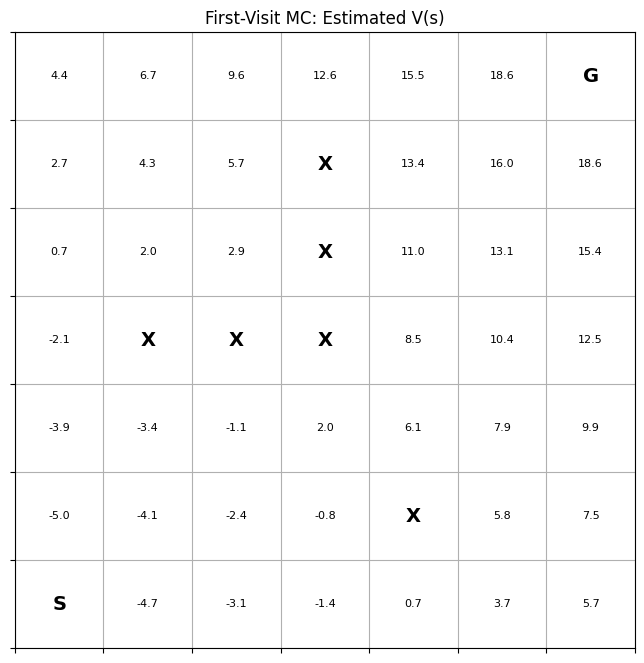

In [18]:
def heuristic_actions(state):
    r, c = state
    preferred = []
    if r > GOAL[0]:
        preferred.append("U")
    if c < GOAL[1]:
        preferred.append("R")
    if r < GOAL[0]:
        preferred.append("D")
    if c > GOAL[1]:
        preferred.append("L")
    return preferred if preferred else ACTIONS.copy()

def sample_prediction_action(state, rng, epsilon=0.35):
    if rng.random() < epsilon:
        return rng.choice(ACTIONS)
    return rng.choice(heuristic_actions(state))

def first_visit_mc_prediction(num_episodes=5000, seed=123, epsilon=0.35):
    rng = random.Random(seed)
    returns = defaultdict(list)
    history = []

    for episode_number in range(1, num_episodes+1):
        state = START
        episode = []

        for _ in range(150):
            action = sample_prediction_action(state, rng, epsilon)
            next_state, reward, done = step(state, action)
            episode.append((state, action, reward, next_state))
            state = next_state
            if done:
                break

        states = [x[0] for x in episode]
        G = 0.0

        for t in range(len(episode)-1, -1, -1):
            state, action, reward, next_state = episode[t]
            G = GAMMA * G + reward

            if state not in states[:t]:
                returns[state].append(G)

        start_value = np.mean(returns[START]) if returns[START] else np.nan
        history.append(start_value)

    V = {s: float(np.mean(v)) for s,v in returns.items()}
    return V, returns, history

V_first, returns_first, first_history = first_visit_mc_prediction()
plot_grid(values=V_first, title="First-Visit MC: Estimated V(s)")

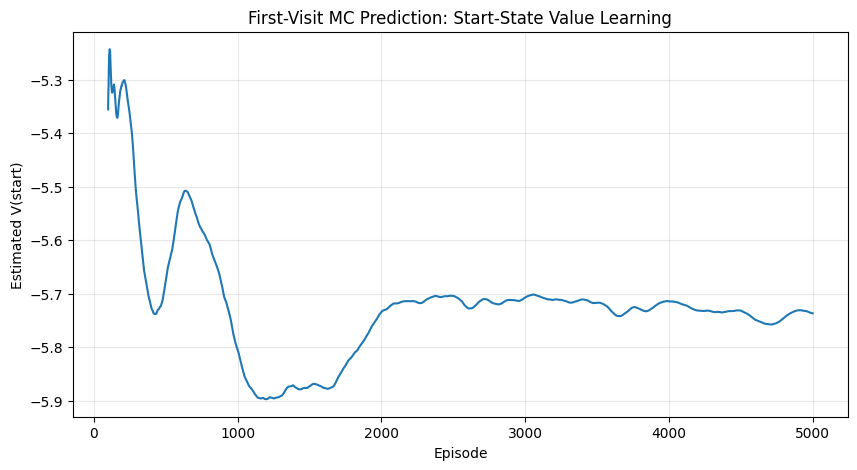

In [19]:
plt.figure(figsize=(10,5))
plt.plot(pd.Series(first_history).rolling(100).mean())
plt.xlabel("Episode")
plt.ylabel("Estimated V(start)")
plt.title("First-Visit MC Prediction: Start-State Value Learning")
plt.grid(alpha=0.3)
plt.show()

# 2. Every-Visit Monte Carlo Prediction

Every-Visit MC uses the same return equation,

$$
\boxed{G\leftarrow \gamma G+R_{t+1}},
$$

but **every occurrence** of a state is used.

Therefore, if a state occurs twice in one episode, both returns are added to that state's return history.

## Complete Worked Episode

Use the same episode so the difference from First-Visit MC is direct:

$$
\left((6, 0),U,-1\right)\rightarrow \left((5, 0),R,-1\right)\rightarrow \left((5, 1),R,-1\right)\rightarrow \left((5, 2),U,-1\right)\rightarrow \left((4, 2),L,-1\right)\rightarrow \left((4, 1),R,-1\right)\rightarrow \left((4, 2),R,-1\right)\rightarrow \left((4, 3),R,-1\right)\rightarrow \left((4, 4),R,-1\right)\rightarrow \left((4, 5),U,-1\right)\rightarrow \left((3, 5),U,-1\right)\rightarrow \left((2, 5),U,-1\right)\rightarrow \left((1, 5),R,-1\right)\rightarrow \left((1, 6),U,20\right)\rightarrow (0, 6)
$$

## Process the Episode Backward

Again initialize

$$
\boxed{G=0}.
$$

This time every backward occurrence updates the value estimate.

### Backward Step 1: $t=13$, state $S_t=(1, 6)$

$$R_{t+1}=20$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(0.000000)+(20)$$

$$\boxed{G=20.000000}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((1, 6))=[20.0]$$

$$N((1, 6))=1$$

$$V((1, 6))=\frac{(20.000000)}{1}=\boxed{20.000000}.$$

### Backward Step 2: $t=12$, state $S_t=(1, 5)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(20.000000)+(-1)$$

$$\boxed{G=18.000000}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((1, 5))=[18.0]$$

$$N((1, 5))=1$$

$$V((1, 5))=\frac{(18.000000)}{1}=\boxed{18.000000}.$$

### Backward Step 3: $t=11$, state $S_t=(2, 5)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(18.000000)+(-1)$$

$$\boxed{G=16.100000}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((2, 5))=[16.099999999999998]$$

$$N((2, 5))=1$$

$$V((2, 5))=\frac{(16.100000)}{1}=\boxed{16.100000}.$$

### Backward Step 4: $t=10$, state $S_t=(3, 5)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(16.100000)+(-1)$$

$$\boxed{G=14.295000}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((3, 5))=[14.294999999999996]$$

$$N((3, 5))=1$$

$$V((3, 5))=\frac{(14.295000)}{1}=\boxed{14.295000}.$$

### Backward Step 5: $t=9$, state $S_t=(4, 5)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(14.295000)+(-1)$$

$$\boxed{G=12.580250}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((4, 5))=[12.580249999999996]$$

$$N((4, 5))=1$$

$$V((4, 5))=\frac{(12.580250)}{1}=\boxed{12.580250}.$$

### Backward Step 6: $t=8$, state $S_t=(4, 4)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(12.580250)+(-1)$$

$$\boxed{G=10.951237}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((4, 4))=[10.951237499999996]$$

$$N((4, 4))=1$$

$$V((4, 4))=\frac{(10.951237)}{1}=\boxed{10.951237}.$$

### Backward Step 7: $t=7$, state $S_t=(4, 3)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(10.951237)+(-1)$$

$$\boxed{G=9.403676}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((4, 3))=[9.403675624999996]$$

$$N((4, 3))=1$$

$$V((4, 3))=\frac{(9.403676)}{1}=\boxed{9.403676}.$$

### Backward Step 8: $t=6$, state $S_t=(4, 2)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(9.403676)+(-1)$$

$$\boxed{G=7.933492}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((4, 2))=[7.933491843749996]$$

$$N((4, 2))=1$$

$$V((4, 2))=\frac{(7.933492)}{1}=\boxed{7.933492}.$$

### Backward Step 9: $t=5$, state $S_t=(4, 1)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(7.933492)+(-1)$$

$$\boxed{G=6.536817}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((4, 1))=[6.536817251562496]$$

$$N((4, 1))=1$$

$$V((4, 1))=\frac{(6.536817)}{1}=\boxed{6.536817}.$$

### Backward Step 10: $t=4$, state $S_t=(4, 2)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(6.536817)+(-1)$$

$$\boxed{G=5.209976}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((4, 2))=[7.933491843749996, 5.209976388984371]$$

$$N((4, 2))=2$$

$$V((4, 2))=\frac{(7.933492)+(5.209976)}{2}=\boxed{6.571734}.$$

### Backward Step 11: $t=3$, state $S_t=(5, 2)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(5.209976)+(-1)$$

$$\boxed{G=3.949478}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((5, 2))=[3.9494775695351523]$$

$$N((5, 2))=1$$

$$V((5, 2))=\frac{(3.949478)}{1}=\boxed{3.949478}.$$

### Backward Step 12: $t=2$, state $S_t=(5, 1)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(3.949478)+(-1)$$

$$\boxed{G=2.752004}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((5, 1))=[2.7520036910583947]$$

$$N((5, 1))=1$$

$$V((5, 1))=\frac{(2.752004)}{1}=\boxed{2.752004}.$$

### Backward Step 13: $t=1$, state $S_t=(5, 0)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(2.752004)+(-1)$$

$$\boxed{G=1.614404}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((5, 0))=[1.6144035065054747]$$

$$N((5, 0))=1$$

$$V((5, 0))=\frac{(1.614404)}{1}=\boxed{1.614404}.$$

### Backward Step 14: $t=0$, state $S_t=(6, 0)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(1.614404)+(-1)$$

$$\boxed{G=0.533683}.$$

Every-Visit MC uses this occurrence, so

$$\text{Returns}((6, 0))=[0.533683331180201]$$

$$N((6, 0))=1$$

$$V((6, 0))=\frac{(0.533683)}{1}=\boxed{0.533683}.$$

## Every-Visit Result from This Episode

For a repeated state such as $(4,2)$, both observed returns are used:

$$
V(4,2)
=
\frac{G^{(1)}(4,2)+G^{(2)}(4,2)}{2}.
$$

After many episodes,

$$
V(s)
=
\frac{\sum \text{all observed returns following }s}
{\text{number of all visits to }s}.
$$

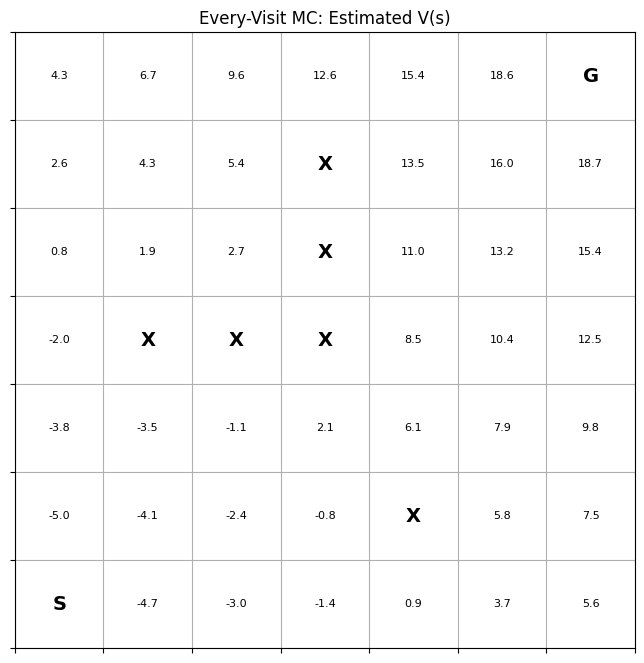

In [20]:
def every_visit_mc_prediction(num_episodes=5000, seed=123, epsilon=0.35):
    rng = random.Random(seed)
    returns = defaultdict(list)
    history = []

    for episode_number in range(1, num_episodes+1):
        state = START
        episode = []

        for _ in range(150):
            action = sample_prediction_action(state, rng, epsilon)
            next_state, reward, done = step(state, action)
            episode.append((state, action, reward, next_state))
            state = next_state
            if done:
                break

        G = 0.0

        for t in range(len(episode)-1, -1, -1):
            state, action, reward, next_state = episode[t]
            G = GAMMA * G + reward
            returns[state].append(G)

        start_value = np.mean(returns[START]) if returns[START] else np.nan
        history.append(start_value)

    V = {s: float(np.mean(v)) for s,v in returns.items()}
    return V, returns, history

V_every, returns_every, every_history = every_visit_mc_prediction()
plot_grid(values=V_every, title="Every-Visit MC: Estimated V(s)")

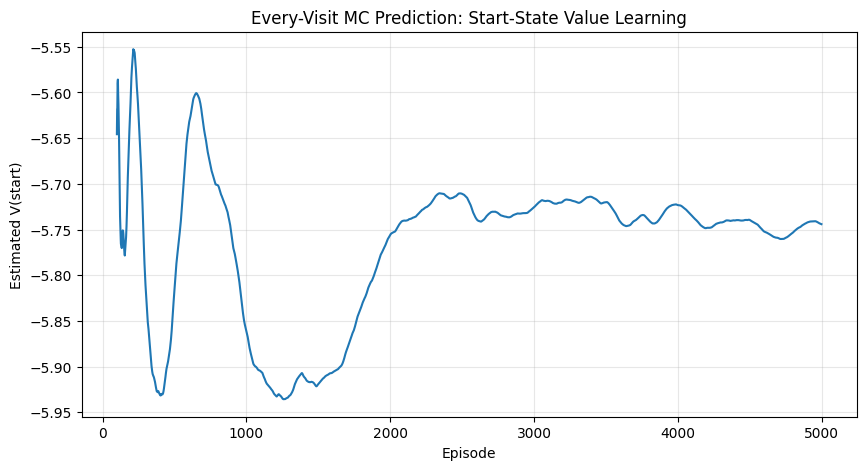

In [21]:
plt.figure(figsize=(10,5))
plt.plot(pd.Series(every_history).rolling(100).mean())
plt.xlabel("Episode")
plt.ylabel("Estimated V(start)")
plt.title("Every-Visit MC Prediction: Start-State Value Learning")
plt.grid(alpha=0.3)
plt.show()

In [22]:
comparison = []
for state in sorted(set(V_first) | set(V_every)):
    comparison.append({
        "State": state,
        "First-Visit V(s)": V_first.get(state, np.nan),
        "Every-Visit V(s)": V_every.get(state, np.nan),
        "Difference": V_every.get(state, np.nan) - V_first.get(state, np.nan)
    })

pd.DataFrame(comparison)

,State,First-Visit V(s),Every-Visit V(s),Difference
0,"(0, 0)",4.393844,4.288298,-0.105546
1,"(0, 1)",6.688623,6.660879,-0.027744
2,"(0, 2)",9.572396,9.629765,0.057369
3,"(0, 3)",12.599539,12.571992,-0.027547
4,"(0, 4)",15.451159,15.425913,-0.025246
5,"(0, 5)",18.581647,18.622510,0.040862
6,"(1, 0)",2.691609,2.639028,-0.052582
7,"(1, 1)",4.296875,4.280374,-0.016501
8,"(1, 2)",5.692719,5.356041,-0.336679
9,"(1, 4)",13.430771,13.468857,0.038086


# 3. On-Policy First-Visit MC Control with $\epsilon$-Greedy Exploration

The control method learns

$$
Q(s,a)
$$

instead of only $V(s)$.

Use

$$
\epsilon=0.15.
$$

With four actions, if one action is greedy,

$$
P(a^*\mid s)
=
1-\epsilon+\frac{\epsilon}{4}
$$

$$
=
1-0.15+\frac{0.15}{4}
$$

$$
=
\boxed{0.8875}.
$$

Each non-greedy action has probability

$$
P(a\mid s)
=
\frac{0.15}{4}
=
\boxed{0.0375}.
$$

## Complete Worked Control Episode

For this worked episode, suppose ties in the current $Q$ table are resolved toward a goal-directed action.

At $(5,0)$, the action $D$ is deliberately sampled as an exploratory action. The episode then returns to the start and follows a goal-directed route.

The complete episode is

$$
\left((6, 0),U,-1\right)\rightarrow \left((5, 0),D,-1\right)\rightarrow \left((6, 0),U,-1\right)\rightarrow \left((5, 0),R,-1\right)\rightarrow \left((5, 1),R,-1\right)\rightarrow \left((5, 2),U,-1\right)\rightarrow \left((4, 2),R,-1\right)\rightarrow \left((4, 3),R,-1\right)\rightarrow \left((4, 4),R,-1\right)\rightarrow \left((4, 5),U,-1\right)\rightarrow \left((3, 5),U,-1\right)\rightarrow \left((2, 5),U,-1\right)\rightarrow \left((1, 5),R,-1\right)\rightarrow \left((1, 6),U,20\right)\rightarrow (0, 6)
$$

The state-action pair

$$
((6,0),U)
$$

appears twice. Because this is **First-Visit MC Control**, only its first occurrence in the original forward episode is used.

In [23]:
manual_control_actions = ['U', 'D', 'U', 'R', 'R', 'U', 'R', 'R', 'R', 'U', 'U', 'U', 'R', 'U']
manual_control_episode = generate_manual_episode(manual_control_actions)

pd.DataFrame(manual_control_episode,
             columns=["State","Action","Reward","Next State"])

,State,Action,Reward,Next State
0,"(6, 0)",U,-1,"(5, 0)"
1,"(5, 0)",D,-1,"(6, 0)"
2,"(6, 0)",U,-1,"(5, 0)"
3,"(5, 0)",R,-1,"(5, 1)"
4,"(5, 1)",R,-1,"(5, 2)"
5,"(5, 2)",U,-1,"(4, 2)"
6,"(4, 2)",R,-1,"(4, 3)"
7,"(4, 3)",R,-1,"(4, 4)"
8,"(4, 4)",R,-1,"(4, 5)"
9,"(4, 5)",U,-1,"(3, 5)"


## $\epsilon$-Greedy Action Probabilities in the Worked Episode

At a visited state, if the selected action is the greedy action,

$$
P(\text{selected greedy action})=0.8875.
$$

For the deliberate exploratory action $D$ at $(5,0)$,

$$
P(D\mid (5,0))=0.0375.
$$

Thus the episode contains both exploitation and exploration.

After the episode finishes, initialize

$$
\boxed{G=0}
$$

and process all state-action pairs backward.

### Backward Step 1: $t=13$, pair $(S_t,A_t)=((1, 6),U)$

$$R_{t+1}=20$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(0.000000)+(20)$$

$$\boxed{G=20.000000}.$$

The pair $((1, 6),U)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((1, 6),U)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((1, 6),U)=0.000000+\frac{1}{1}[20.000000-(0.000000)]$$

$$\boxed{Q((1, 6),U)=20.000000}.$$

### Backward Step 2: $t=12$, pair $(S_t,A_t)=((1, 5),R)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(20.000000)+(-1)$$

$$\boxed{G=18.000000}.$$

The pair $((1, 5),R)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((1, 5),R)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((1, 5),R)=0.000000+\frac{1}{1}[18.000000-(0.000000)]$$

$$\boxed{Q((1, 5),R)=18.000000}.$$

### Backward Step 3: $t=11$, pair $(S_t,A_t)=((2, 5),U)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(18.000000)+(-1)$$

$$\boxed{G=16.100000}.$$

The pair $((2, 5),U)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((2, 5),U)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((2, 5),U)=0.000000+\frac{1}{1}[16.100000-(0.000000)]$$

$$\boxed{Q((2, 5),U)=16.100000}.$$

### Backward Step 4: $t=10$, pair $(S_t,A_t)=((3, 5),U)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(16.100000)+(-1)$$

$$\boxed{G=14.295000}.$$

The pair $((3, 5),U)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((3, 5),U)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((3, 5),U)=0.000000+\frac{1}{1}[14.295000-(0.000000)]$$

$$\boxed{Q((3, 5),U)=14.295000}.$$

### Backward Step 5: $t=9$, pair $(S_t,A_t)=((4, 5),U)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(14.295000)+(-1)$$

$$\boxed{G=12.580250}.$$

The pair $((4, 5),U)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((4, 5),U)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((4, 5),U)=0.000000+\frac{1}{1}[12.580250-(0.000000)]$$

$$\boxed{Q((4, 5),U)=12.580250}.$$

### Backward Step 6: $t=8$, pair $(S_t,A_t)=((4, 4),R)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(12.580250)+(-1)$$

$$\boxed{G=10.951237}.$$

The pair $((4, 4),R)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((4, 4),R)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((4, 4),R)=0.000000+\frac{1}{1}[10.951237-(0.000000)]$$

$$\boxed{Q((4, 4),R)=10.951237}.$$

### Backward Step 7: $t=7$, pair $(S_t,A_t)=((4, 3),R)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(10.951237)+(-1)$$

$$\boxed{G=9.403676}.$$

The pair $((4, 3),R)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((4, 3),R)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((4, 3),R)=0.000000+\frac{1}{1}[9.403676-(0.000000)]$$

$$\boxed{Q((4, 3),R)=9.403676}.$$

### Backward Step 8: $t=6$, pair $(S_t,A_t)=((4, 2),R)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(9.403676)+(-1)$$

$$\boxed{G=7.933492}.$$

The pair $((4, 2),R)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((4, 2),R)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((4, 2),R)=0.000000+\frac{1}{1}[7.933492-(0.000000)]$$

$$\boxed{Q((4, 2),R)=7.933492}.$$

### Backward Step 9: $t=5$, pair $(S_t,A_t)=((5, 2),U)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(7.933492)+(-1)$$

$$\boxed{G=6.536817}.$$

The pair $((5, 2),U)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((5, 2),U)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((5, 2),U)=0.000000+\frac{1}{1}[6.536817-(0.000000)]$$

$$\boxed{Q((5, 2),U)=6.536817}.$$

### Backward Step 10: $t=4$, pair $(S_t,A_t)=((5, 1),R)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(6.536817)+(-1)$$

$$\boxed{G=5.209976}.$$

The pair $((5, 1),R)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((5, 1),R)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((5, 1),R)=0.000000+\frac{1}{1}[5.209976-(0.000000)]$$

$$\boxed{Q((5, 1),R)=5.209976}.$$

### Backward Step 11: $t=3$, pair $(S_t,A_t)=((5, 0),R)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(5.209976)+(-1)$$

$$\boxed{G=3.949478}.$$

The pair $((5, 0),R)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((5, 0),R)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((5, 0),R)=0.000000+\frac{1}{1}[3.949478-(0.000000)]$$

$$\boxed{Q((5, 0),R)=3.949478}.$$

### Backward Step 12: $t=2$, pair $(S_t,A_t)=((6, 0),U)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(3.949478)+(-1)$$

$$\boxed{G=2.752004}.$$

The pair $((6, 0),U)$ already appeared earlier at $t=0$, so this later occurrence is ignored.

\[\boxed{\text{No }Q\text{ update for this occurrence}}\]

### Backward Step 13: $t=1$, pair $(S_t,A_t)=((5, 0),D)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(2.752004)+(-1)$$

$$\boxed{G=1.614404}.$$

The pair $((5, 0),D)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((5, 0),D)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((5, 0),D)=0.000000+\frac{1}{1}[1.614404-(0.000000)]$$

$$\boxed{Q((5, 0),D)=1.614404}.$$

### Backward Step 14: $t=0$, pair $(S_t,A_t)=((6, 0),U)$

$$R_{t+1}=-1$$

$$G\leftarrow \gamma G+R_{t+1}$$

$$G=(0.95)(1.614404)+(-1)$$

$$\boxed{G=0.533683}.$$

The pair $((6, 0),U)$ did not appear earlier in the episode, so it is a **First-Visit state-action pair**.

$$N((6, 0),U)=0+1=\boxed{1}.$$

The sample-average update is

$$Q(s,a)\leftarrow Q(s,a)+\frac{1}{N(s,a)}[G-Q(s,a)].$$

$$Q((6, 0),U)=0.000000+\frac{1}{1}[0.533683-(0.000000)]$$

$$\boxed{Q((6, 0),U)=0.533683}.$$

## Policy Improvement after the Episode

After each updated state-action pair,

$$
a^*(s)=\arg\max_aQ(s,a).
$$

The new $\epsilon$-greedy policy is

$$
\pi(a\mid s)
=
\begin{cases}
0.8875, & a=a^*(s),\\
0.0375, & a\neq a^*(s).
\end{cases}
$$

For pairs whose updated $Q(s,a)$ is larger than the still-unvisited actions with value $0$, the sampled action becomes the greedy action.

This completes one full control cycle:

$$
\boxed{
\epsilon\text{-greedy action selection}
\rightarrow
\text{episode}
\rightarrow
G
\rightarrow
Q
\rightarrow
\text{improved }\epsilon\text{-greedy policy}
}.
$$

# Train the MC Control Agent

Now train from the fixed start state $(6,0)$ over many episodes.

The First-Visit sample-average update is

$$
N(s,a)\leftarrow N(s,a)+1
$$

and

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\frac{1}{N(s,a)}
\left[
G-Q(s,a)
\right].
$$

The exploration rate is gradually reduced during training.

In [24]:
def epsilon_greedy_action(state, Q, epsilon, rng):
    if rng.random() < epsilon:
        return rng.choice(ACTIONS)

    values = [Q[(state,a)] for a in ACTIONS]
    best = max(values)
    best_actions = [a for a,v in zip(ACTIONS,values) if v == best]
    return rng.choice(best_actions)

def train_mc_control(
    num_episodes=20000,
    epsilon_start=0.25,
    epsilon_min=0.02,
    epsilon_decay=0.9996,
    max_steps=180,
    seed=42
):
    rng = random.Random(seed)
    Q = defaultdict(float)
    N = defaultdict(int)

    returns_history = []
    lengths_history = []
    success_history = []
    epsilon_history = []

    epsilon = epsilon_start

    for episode_number in range(1, num_episodes+1):
        state = START
        episode = []
        done = False

        for _ in range(max_steps):
            action = epsilon_greedy_action(state, Q, epsilon, rng)
            next_state, reward, done = step(state, action)
            episode.append((state, action, reward, next_state))
            state = next_state
            if done:
                break

        returns_history.append(sum(x[2] for x in episode))
        lengths_history.append(len(episode))
        success_history.append(int(done))
        epsilon_history.append(epsilon)

        pairs = [(x[0],x[1]) for x in episode]
        G = 0.0

        for t in range(len(episode)-1, -1, -1):
            state, action, reward, next_state = episode[t]
            G = GAMMA * G + reward
            pair = (state, action)

            if pair not in pairs[:t]:
                N[pair] += 1
                Q[pair] += (G - Q[pair]) / N[pair]

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    stats = pd.DataFrame({
        "Episode": np.arange(1, num_episodes+1),
        "Return": returns_history,
        "Length": lengths_history,
        "Success": success_history,
        "Epsilon": epsilon_history
    })

    return Q, N, stats

Q_learned, N_learned, training_stats = train_mc_control()
training_stats.tail()

,Episode,Return,Length,Success,Epsilon
19995,19996,9,12,1,0.02
19996,19997,9,12,1,0.02
19997,19998,9,12,1,0.02
19998,19999,9,12,1,0.02
19999,20000,9,12,1,0.02


# Learned Policy

After training, exploration is removed for evaluation and the greedy policy is

$$
\boxed{
\pi(s)=\arg\max_a Q(s,a)
}.
$$

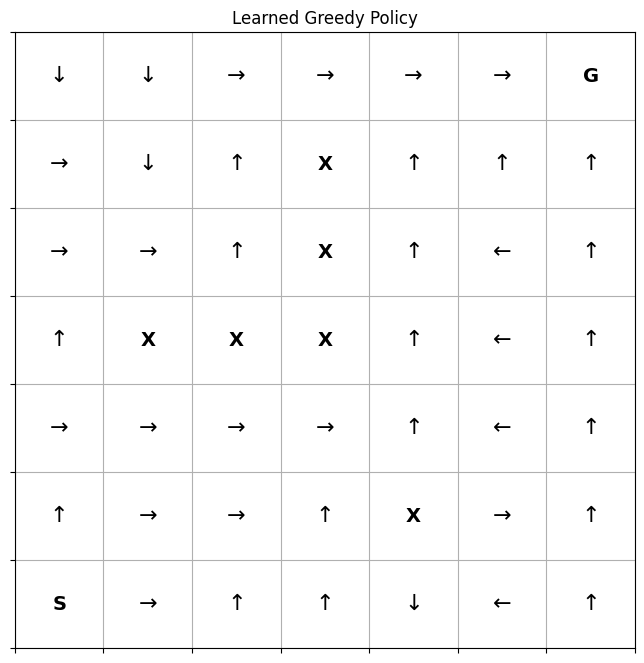

In [25]:
ACTION_ORDER = {"U":0, "R":1, "D":2, "L":3}

def learned_policy(Q):
    policy = {}

    for state in STATES:
        if state == GOAL:
            continue

        values = {a:Q[(state,a)] for a in ACTIONS}
        best = max(values.values())
        candidates = [a for a,v in values.items() if v == best]
        policy[state] = sorted(candidates, key=lambda a:ACTION_ORDER[a])[0]

    return policy

policy = learned_policy(Q_learned)
plot_grid(policy=policy, title="Learned Greedy Policy")

# Learning Graphs

A moving average is used so the learning trend is easier to read.

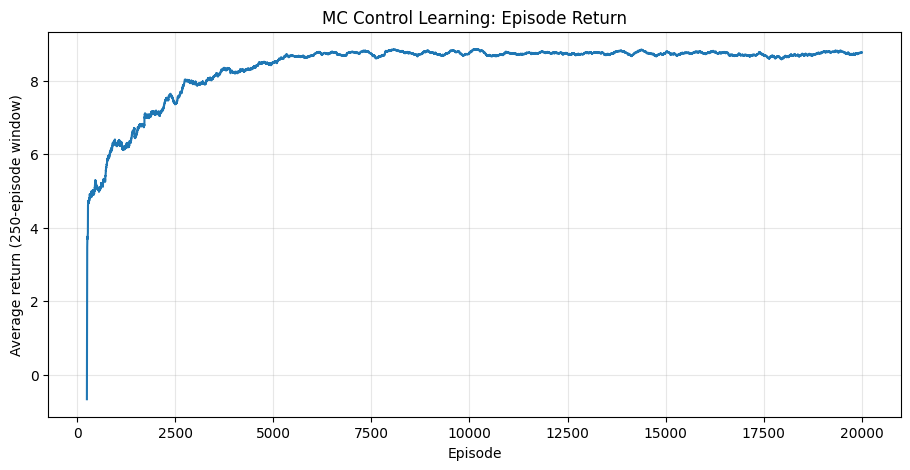

In [26]:
window = 250
training_stats["Return MA"] = training_stats["Return"].rolling(window).mean()
training_stats["Length MA"] = training_stats["Length"].rolling(window).mean()
training_stats["Success MA"] = training_stats["Success"].rolling(window).mean()

plt.figure(figsize=(11,5))
plt.plot(training_stats["Episode"], training_stats["Return MA"])
plt.xlabel("Episode")
plt.ylabel(f"Average return ({window}-episode window)")
plt.title("MC Control Learning: Episode Return")
plt.grid(alpha=0.3)
plt.show()

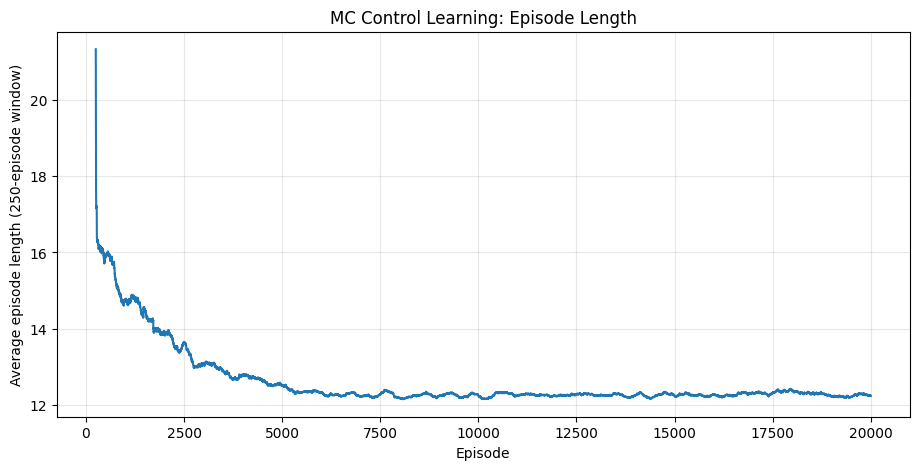

In [27]:
plt.figure(figsize=(11,5))
plt.plot(training_stats["Episode"], training_stats["Length MA"])
plt.xlabel("Episode")
plt.ylabel(f"Average episode length ({window}-episode window)")
plt.title("MC Control Learning: Episode Length")
plt.grid(alpha=0.3)
plt.show()

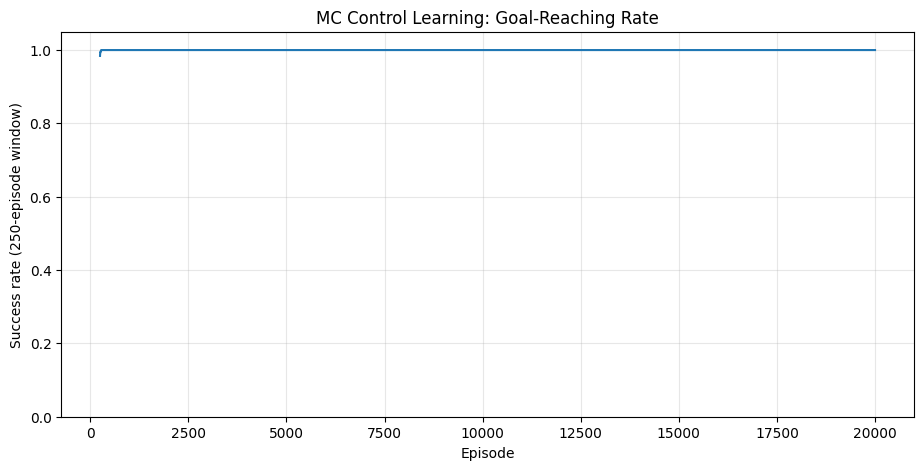

In [28]:
plt.figure(figsize=(11,5))
plt.plot(training_stats["Episode"], training_stats["Success MA"])
plt.xlabel("Episode")
plt.ylabel(f"Success rate ({window}-episode window)")
plt.title("MC Control Learning: Goal-Reaching Rate")
plt.ylim(0,1.05)
plt.grid(alpha=0.3)
plt.show()

# Simulation Using the Learned Policy

The simulation uses no exploration.

At every state,

$$
A_t=\arg\max_aQ(S_t,a).
$$

For each simulated step, the notebook prints

$$
S_t,\quad A_t,\quad R_{t+1},\quad S_{t+1}.
$$

In [29]:
def greedy_action(state, Q):
    values = {a:Q[(state,a)] for a in ACTIONS}
    best = max(values.values())
    candidates = [a for a,v in values.items() if v == best]
    return sorted(candidates, key=lambda a:ACTION_ORDER[a])[0]

def simulate_policy(Q, max_steps=100):
    state = START
    path = [state]
    rows = []
    total_reward = 0

    for t in range(max_steps):
        action = greedy_action(state, Q)
        next_state, reward, done = step(state, action)
        total_reward += reward

        rows.append({
            "t":t,
            "S_t":state,
            "A_t":action,
            "R_(t+1)":reward,
            "S_(t+1)":next_state,
            "Cumulative reward":total_reward
        })

        state = next_state
        path.append(state)

        if done:
            break

    return pd.DataFrame(rows), path, total_reward, state == GOAL

simulation, learned_path, total_reward, success = simulate_policy(Q_learned)
simulation

,t,S_t,A_t,R_(t+1),S_(t+1),Cumulative reward
0,0,"(6, 0)",U,-1,"(5, 0)",-1
1,1,"(5, 0)",U,-1,"(4, 0)",-2
2,2,"(4, 0)",R,-1,"(4, 1)",-3
3,3,"(4, 1)",R,-1,"(4, 2)",-4
4,4,"(4, 2)",R,-1,"(4, 3)",-5
5,5,"(4, 3)",R,-1,"(4, 4)",-6
6,6,"(4, 4)",U,-1,"(3, 4)",-7
7,7,"(3, 4)",U,-1,"(2, 4)",-8
8,8,"(2, 4)",U,-1,"(1, 4)",-9
9,9,"(1, 4)",U,-1,"(0, 4)",-10


In [30]:
print("Reached goal:", success)
print("Steps:", len(simulation))
print("Total reward:", total_reward)
print("Learned path:")
print(" -> ".join(map(str, learned_path)))

Reached goal: True
Steps: 12
Total reward: 9
Learned path:
(6, 0) -> (5, 0) -> (4, 0) -> (4, 1) -> (4, 2) -> (4, 3) -> (4, 4) -> (3, 4) -> (2, 4) -> (1, 4) -> (0, 4) -> (0, 5) -> (0, 6)


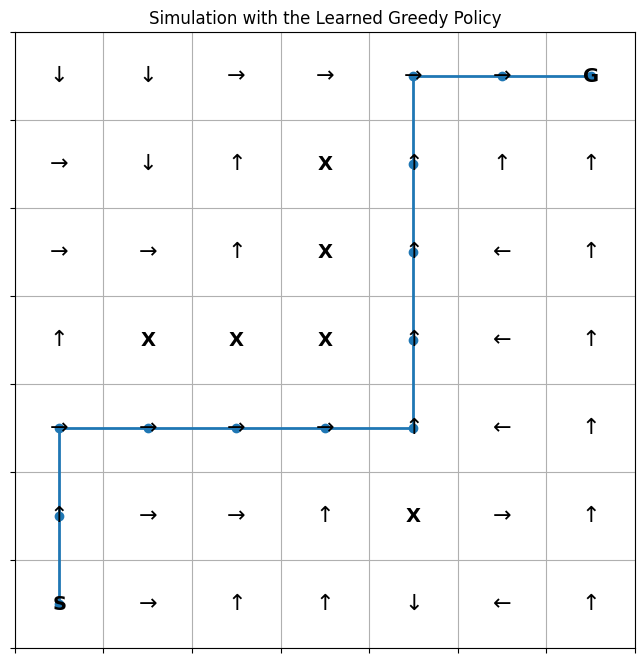

In [31]:
plot_grid(
    policy=policy,
    path=learned_path,
    title="Simulation with the Learned Greedy Policy"
)